In [1]:
import networkx as nx
import json
import math
import matplotlib.pyplot as plt

In [2]:
DIRECTION_SPACING = 25
SWITCH_ABBREVIATIONS = ["sr", "sl"]
CURVE_ABBREVIATIONS = ["cr", "cl"]

file_path = "./saved_tracks/timesaver.json"

In [3]:
with open(file_path) as file:
    system = json.load(file)

## Gernerieren des gerichteten Line-Graphs
1. je nach Gleissegment-Typ (Gerade, Kurver oder Weiche) für alle erlaubten Übergänge Knoten erzeugen
2. gerichtete Kanten an den Anschlüssen zu den jeweils eralaubten, benachbarten, Gleissegmenten erzeugen 

In [4]:
G = nx.DiGraph()
nodes = []
edges = []
pos = {}

In [5]:
def get_curve_edge_position(a_coords: list, a_heading: float, angle: float, radius: float, dir: str, from_a: bool):

    # if either transition starts at a-end of right curve or at b-end (c-end in case of switch) of left curve
    signed_direction_spacing = -DIRECTION_SPACING/2 if from_a != (dir == "l") else DIRECTION_SPACING/2

    a_x, a_y = a_coords

    if dir == "r":
        return (
            a_x + radius * math.sin(math.radians(a_heading + 90)) + (radius + signed_direction_spacing) * math.sin(math.radians(a_heading + 270 + angle/2)),
            a_y + radius * math.cos(math.radians(a_heading + 90)) + (radius + signed_direction_spacing) * math.cos(math.radians(a_heading + 270 + angle/2))
        )
    else:
        return (
            a_x + radius * math.sin(math.radians(a_heading + 270)) + (radius + signed_direction_spacing) * math.sin(math.radians(a_heading + 90 - angle/2)),
            a_y + radius * math.cos(math.radians(a_heading + 270)) + (radius + signed_direction_spacing) * math.cos(math.radians(a_heading + 90 - angle/2))
        )


In [6]:
def get_straight_edge_position(a_coords: list, a_heading: float, length: float, from_a: bool):
    signed_direction_spacing = DIRECTION_SPACING/2 if from_a else -DIRECTION_SPACING/2   
    return (
        a_coords[0] + length/2 * math.sin(math.radians(a_heading)) + signed_direction_spacing * math.cos(math.radians(a_heading)),
        a_coords[1] + length/2 * math.cos(math.radians(a_heading)) - signed_direction_spacing * math.sin(math.radians(a_heading))
    )

In [7]:
def get_edge_position(segment: object, from_end: str, to_end: str):
    segment_type = segment["type"]

    coords = segment["location"]["a"]
    heading = segment["metadata"]["coords"][2]
    starting_end = segment["metadata"]["starting_end"]

    if segment_type in CURVE_ABBREVIATIONS or segment_type in SWITCH_ABBREVIATIONS:
        dir = segment["metadata"]["dir"]
        radius = segment["metadata"]["radius"]
        angle = segment["metadata"]["angle"]

    # straight
    if segment_type == "st":
        if starting_end == "b": heading += 180
        return get_straight_edge_position(coords, heading, segment["metadata"]["length_a.b"], from_end == "a")
    
    # curve
    elif segment_type in CURVE_ABBREVIATIONS:
        if starting_end == "b":
            if segment["metadata"]["dir"] == "r": heading += 150
            else: heading += 210
        return get_curve_edge_position(coords, heading, angle, radius, dir, from_end == "a")
    
    # switch
    elif segment_type in SWITCH_ABBREVIATIONS:
        # transition is for straight segment of switch
        if starting_end == "b": heading += 180
        elif starting_end == "c":
            if segment["metadata"]["dir"] == "r": heading += 150
            else: heading += 210
        # transition for curve segment of switch
        if from_end in ["a", "b"] and to_end in ["a", "b"]:
            return get_straight_edge_position(coords, heading, segment["metadata"]["length_a.b"], from_end == "a")
        else:
            return get_curve_edge_position(coords, heading, angle, radius, dir, from_end == "a")



In [8]:
for segment_id, segment in system['segments'].items():
    segment_type = segment["type"]
    segment_ends = segment["connections"]

    # nodes[f"{segment_id}.b_a"] = {"length": segment["metadata"]["length_a.b"]}
    # nodes[f"{segment_id}.a_b"] = {"length": segment["metadata"]["length_a.b"]}
    nodes.append((f"{segment_id}.b_a", {"length": segment["metadata"]["length_a.b"]}))
    nodes.append((f"{segment_id}.a_b", {"length": segment["metadata"]["length_a.b"]}))
    
    if segment_type not in CURVE_ABBREVIATIONS:
        pos[f"{segment_id}.b_a"] = get_edge_position(segment, "b", "a")
        pos[f"{segment_id}.a_b"] = get_edge_position(segment, "a", "b")
    else:
        pos[f"{segment_id}.b_a"] = get_edge_position(segment, "b", "a")
        pos[f"{segment_id}.a_b"] = get_edge_position(segment, "a", "b")

    if segment_type in SWITCH_ABBREVIATIONS:
        # nodes[f"{segment_id}.c_a"] = f"{segment_id}.c_a"
        # nodes[f"{segment_id}.a_c"] = f"{segment_id}.a_c"
        nodes.append((f"{segment_id}.c_a", {"length": segment["metadata"]["length_a.b"]}))
        nodes.append((f"{segment_id}.a_c", {"length": segment["metadata"]["length_a.c"]}))
        pos[f"{segment_id}.c_a"] = get_edge_position(segment, "c", "a")
        pos[f"{segment_id}.a_c"] = get_edge_position(segment, "a", "c")

for segment_id, segment in system['segments'].items():
    segment_ends = segment["connections"]
    for end, transition in segment_ends.items():

        connected_id = transition.split('.')[0] if transition != None else "None"
        connected_type = system['segments'][connected_id]['type'] if transition != None else "None"
        connected_end = transition.split('.')[1] if transition != None else "None"

        opposite_ends = ["a" if end in ["b", "c"] else "b"]
        if end == "a" and segment["type"] in SWITCH_ABBREVIATIONS: # if segment is of type switch and end is "a", add "c" to opposite ends
            opposite_ends.append("c")

        own_directional_edges = []
        for opposite_end in opposite_ends:
            own_directional_edges.append(f"{segment_id}.{opposite_end}_{end}")

        # if end is connected to a root-end of a switch, add transition-edge to the diverging branch-end (c)
        if connected_type in SWITCH_ABBREVIATIONS and connected_end == "a":
            for own_directional_edge in own_directional_edges:
                edges.append((own_directional_edge, f"{connected_id}.a_c", {"virtual_saw": False}))
        for own_directional_edge in own_directional_edges:
            if connected_id != "None":
                edges.append((own_directional_edge, f"{connected_id}.{connected_end}_{"b" if connected_end == "a" else "a"}", {"virtual_saw": False}))
    
    # if segment is of type switch, add virtual edges, that connect branch ends for saw-routes
    if segment["type"] in SWITCH_ABBREVIATIONS:
        print("adding virtual nodes")
        edges.append((f"{segment_id}.c_a", f"{segment_id}.a_b", {"virtual_saw": True}))
        edges.append((f"{segment_id}.b_a", f"{segment_id}.a_c", {"virtual_saw": True}))

adding virtual nodes
adding virtual nodes
adding virtual nodes
adding virtual nodes
adding virtual nodes
adding virtual nodes


In [9]:
edges

[('7e5e66e0-9267-4f7a-8c88-82a28baa69d9.a_b',
  'a831bc24-131f-4864-95f4-3636f0c4bebc.a_b',
  {'virtual_saw': False}),
 ('a831bc24-131f-4864-95f4-3636f0c4bebc.b_a',
  '7e5e66e0-9267-4f7a-8c88-82a28baa69d9.b_a',
  {'virtual_saw': False}),
 ('a831bc24-131f-4864-95f4-3636f0c4bebc.a_b',
  'acf9576d-79b1-443d-8f58-cb6fc528c137.a_b',
  {'virtual_saw': False}),
 ('acf9576d-79b1-443d-8f58-cb6fc528c137.b_a',
  'a831bc24-131f-4864-95f4-3636f0c4bebc.b_a',
  {'virtual_saw': False}),
 ('acf9576d-79b1-443d-8f58-cb6fc528c137.a_b',
  'd9d4a3ec-2a09-43c1-ace3-8f287a364a42.a_c',
  {'virtual_saw': False}),
 ('acf9576d-79b1-443d-8f58-cb6fc528c137.a_b',
  'd9d4a3ec-2a09-43c1-ace3-8f287a364a42.a_b',
  {'virtual_saw': False}),
 ('d9d4a3ec-2a09-43c1-ace3-8f287a364a42.b_a',
  'acf9576d-79b1-443d-8f58-cb6fc528c137.b_a',
  {'virtual_saw': False}),
 ('d9d4a3ec-2a09-43c1-ace3-8f287a364a42.c_a',
  'acf9576d-79b1-443d-8f58-cb6fc528c137.b_a',
  {'virtual_saw': False}),
 ('d9d4a3ec-2a09-43c1-ace3-8f287a364a42.a_b',
  

In [10]:
G.add_nodes_from(nodes)
G.add_edges_from(edges)

In [11]:
x_coords = [pos[node][0] for node in G.nodes()]
y_coords = [pos[node][1] for node in G.nodes()]
spread_x = max(x_coords) - min(x_coords)
spread_y = max(y_coords) - min(y_coords)


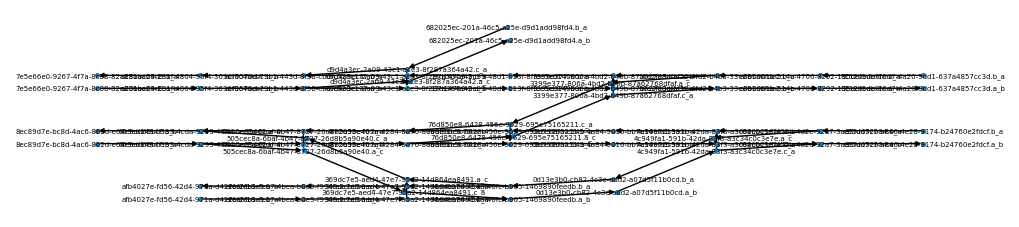

In [12]:
plt.figure(figsize=(10, 10 * spread_y / spread_x))
nx.draw(G, pos=pos, node_size=7, arrowsize=7, with_labels=True, font_size=5)
plt.savefig(f"imgoutput/{file_path.replace('.json', '.svg')}")
plt.show()


In [13]:
# from pathfinding_strategies.DijkstraRail import DijkstraRail
from strategies.pathfinding import DijkstraRail

In [14]:
dijkstra_rail = DijkstraRail()

In [15]:
nodes

[('7e5e66e0-9267-4f7a-8c88-82a28baa69d9.b_a', {'length': 200}),
 ('7e5e66e0-9267-4f7a-8c88-82a28baa69d9.a_b', {'length': 200}),
 ('a831bc24-131f-4864-95f4-3636f0c4bebc.b_a', {'length': 200}),
 ('a831bc24-131f-4864-95f4-3636f0c4bebc.a_b', {'length': 200}),
 ('acf9576d-79b1-443d-8f58-cb6fc528c137.b_a', {'length': 200}),
 ('acf9576d-79b1-443d-8f58-cb6fc528c137.a_b', {'length': 200}),
 ('d9d4a3ec-2a09-43c1-ace3-8f287a364a42.b_a', {'length': 200}),
 ('d9d4a3ec-2a09-43c1-ace3-8f287a364a42.a_b', {'length': 200}),
 ('d9d4a3ec-2a09-43c1-ace3-8f287a364a42.c_a', {'length': 200}),
 ('d9d4a3ec-2a09-43c1-ace3-8f287a364a42.a_c', {'length': 209.43951023931953}),
 ('13d14759-9c99-48d1-b13f-8ffee5eb140b.b_a', {'length': 200}),
 ('13d14759-9c99-48d1-b13f-8ffee5eb140b.a_b', {'length': 200}),
 ('3399e377-806a-4bd2-b49b-87a62768dfaf.b_a', {'length': 200}),
 ('3399e377-806a-4bd2-b49b-87a62768dfaf.a_b', {'length': 200}),
 ('3399e377-806a-4bd2-b49b-87a62768dfaf.c_a', {'length': 200}),
 ('3399e377-806a-4bd2-b49

In [ ]:
path = dijkstra_rail.find_path(G, "100c0cab-3852-4b2b-ac73-22be8f167233.", "071baa15-6ff7-47b0-98ab-798009858121.", 400, 1, shunting_overrun_penalty=600, initial_orientation="a_b")

NetworkXError: The node 100c0cab-3852-4b2b-ac73-22be8f167233.a_b is not in the digraph.

In [ ]:
path

In [ ]:
node_colors = [node[0] for node in nodes]
for i, node_color in enumerate(node_colors):
    if node_color in path:
        node_colors[i] = "red"
    else: node_colors[i] = "black"

In [ ]:
plt.figure(figsize=(10, 10 * spread_y / spread_x))
nx.draw(G, pos=pos, node_size=7, arrowsize=7, node_color=node_colors, font_size=5, with_labels=False)
plt.savefig(f"imgoutput/{file_path.replace('.json', '.svg')}")
plt.show()

In [ ]:
path

In [ ]:

G.edges.get(('4.b_a', '3.b_a'))

In [ ]:
list(G.neighbors("2.b_a"))

In [ ]:
G.nodes.get("2.a_b")["length"]

In [ ]:
G.get_edge_data("2.b_a", "3.a_c")

In [ ]:
start_node = "15.b_a"
req_dist =  1000

In [ ]:
# unvisited = set()
# visited = set()
# initial_neighbors = list(G.neighbors(start_node))
# for initial_neighbor in initial_neighbors:
#     if not G.get_edge_data(start_node, initial_neighbor).get("virtual_saw"):
#         unvisited.add((
#                 G.nodes.get(start_node)["length"]/2 + G.nodes.get(initial_neighbor)["length"]/2,
#                 initial_neighbor,
#                 None
#         ))


In [ ]:
# test = set()
# test.add(("a", 1, True))
# test.add(("b", 2, False))
# test

In [ ]:
def build_dfs_path(visited: set, last: str) -> list:
    path = []
    curr = last

    parent_map = {node: (dist, prev) for dist, node, prev, visited_segments in visited}

    while curr:
        dist, prev = parent_map[curr]
        path.append((curr))
        curr = prev

    path.reverse()
    return path


In [ ]:
# def dfs_rail(graph: nx.DiGraph, start_node: str, req_dist_1: int, req_dist_2: int = None) -> tuple:
#     """
#     depth first search algorithm, adapted for rail-based scenarios
    
#         params:
#         - graph: networkx DiGraph representation of the rail system
#         - start_node: id of the start node
#         - req_dist_1: required distance to the reference point (e.g. wagons behind the locomotive + part of the locomotive behind the reference point)
#         - req_dist_2: optional: requiered distance from the reference point (e.g. for the part of the locomotive in front of the reference point + pushed wagons)
    
#         returns:
#         tuple, containing:
#             [0]: list of all nodes to the first possible return node
#             [1]: distance to the first possible return node (e.g. to use for virtual saw edges in pathfinding algorithms)

#     """
#     visited = set()
#     unvisited = set()
#     unvisited.add((0, start_node, None, (start_node.split(".")[0],)))
#     while unvisited:
#         next = min(unvisited)
#         visited.add(next)
#         dist, curr, prev, visited_segments = next
#         if dist >= req_dist_1:
#             if not req_dist_2 or (dfs_rail(graph, curr, req_dist_2)[1] > 0):
#                 return (build_dfs_path(visited, curr), dist)
#         next_neighbors = list(graph.neighbors(curr))
#         for next_neighbor in next_neighbors:
#             if str(next_neighbor).split(".")[0] not in visited_segments:  # as neighbor-node of virtual saw edge is of the same segment, this also prohibits using branch-branch edges for dfs           
#                 new_segments = visited_segments + (str(next_neighbor).split(".")[0],)

#                 unvisited.add(
#                     (
#                         dist + graph.nodes.get(curr)["length"]/2 + graph.nodes.get(next_neighbor)["length"]/2,
#                         next_neighbor,
#                         curr,
#                         new_segments
#                     )
#                 )
#         unvisited.remove(next)
#     return ([], 0)


In [ ]:
def dfs_rail(graph: nx.DiGraph, start_node: str, req_dist_1: int, req_dist_2: int = None) -> tuple:
    """
    depth first search algorithm, adapted for rail-based scenarios
    
        params:
        - graph: networkx DiGraph representation of the rail system
        - start_node: id of the start node
        - req_dist_1: required distance to the reference point (e.g. wagons behind the locomotive + part of the locomotive behind the reference point)
        - req_dist_2: optional: requiered distance from the reference point (e.g. for the part of the locomotive in front of the reference point + pushed wagons)
    
        returns:
        tuple, containing:
            [0]: list of all nodes to the first possible return node
            [1]: distance to the first possible return node (e.g. to use for virtual saw edges in pathfinding algorithms)

    """
    visited = set()
    unvisited = [(0, start_node, None, (start_node.split(".")[0],))]

    while unvisited:
        dist, curr, prev, visited_segments = unvisited.pop()
        state = (dist, curr, prev, visited_segments)
        if state in visited:
            continue
        visited.add(state)

        if dist >= req_dist_1:
            if not req_dist_2 or (dfs_rail(graph, curr, req_dist_2)[1] > 0):
                return (build_dfs_path(visited, curr), dist)

        for next_neighbor in graph.neighbors(curr):
            neighbor_segment = str(next_neighbor).split(".")[0]
            if neighbor_segment not in visited_segments:  # as neighbor-node of virtual saw edge is of the same segment, this also prohibits using branch-branch edges for dfs           
                new_segments = visited_segments + (neighbor_segment,)

                unvisited.append(
                    (
                        dist + graph.nodes.get(curr)["length"]/2 + graph.nodes.get(next_neighbor)["length"]/2,
                        next_neighbor,
                        curr,
                        new_segments
                    )
                )
    return ([], 0.0)


In [ ]:
from strategies.distance_checks import BaseDistanceCheck, DFSRail

check_available_distance: BaseDistanceCheck.check_distance = DFSRail().check_distance

check_available_distance(G, "2.b_a", 1023, 201)


In [ ]:
check_available_distance(G, "2.b_a", 1000)

In [ ]:
# dfs_rail(G, "2.b_a", 1023, 201)

In [ ]:


while unvisited:
    next = max(unvisited)
    visited.add(next)
    dist, curr, prev = next
    if dist >= req_dist:
        print(build_dfs_path(visited, curr))
    next_neighbors = list(G.neighbors(curr))
    for next_neighbor in next_neighbors:
        if not G.get_edge_data(curr, next_neighbor).get("virtual_saw"):
            unvisited.add(
                (
                    dist + G.nodes.get(start_node)["length"]/2 + G.nodes.get(initial_neighbor)["length"]/2,
                    next_neighbor,
                    curr
                )
            )

    unvisited.remove(next)

In [ ]:
visited